# Jupyter Notebook 2. Эксперименты с моделями и валидация

**Стажёр:** [Парцей Петр]

На входе — готовый датасет, подготовленный ранее и разделённый на тренировочную и тестовую выборки.

На выходе — финальная модель, карточка модели и SHAP-анализ.

## 1. Подключение библиотек

In [ ]:
!pip install optuna shap boto3 python-dotenv -q

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import StratifiedKFold, cross_validate


from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
import catboost as cb
import optuna
import shap
import io
import os
import boto3
import botocore
from dotenv import load_dotenv
import pickle
import re
import ast

In [2]:
RANDOM_STATE = 42

In [3]:
# Отключаем агрессивное приведение к PyArrow-строкам для обработки признака 'amenities'
pd.set_option("future.infer_string", False)

## 2. Загрузка данных

Загрузите `train` и `test` выборки из тетради 1. Проверьте размеры выборок и баланс классов.

In [4]:
# Загрузка
df = joblib.load('ready_dataset.joblib')

# Быстрое восстановление выборок без повторного разбиения
train_part = df[df['split'] == 'train'].drop(columns=['split'])
test_part = df[df['split'] == 'test'].drop(columns=['split'])

X_train = train_part.drop(columns=['is_high_demand'])
y_train = train_part['is_high_demand']

X_test = test_part.drop(columns=['is_high_demand'])
y_test = test_part['is_high_demand']

Проверяем размер выборок:

In [5]:
print(f'Размер train: {len(y_train):,} объектов')
print(f'Размер test:  {len(y_test):,} объектов')
print(f'Всего:        {len(y_train) + len(y_test):,} объектов')

Размер train: 121,676 объектов
Размер test:  30,420 объектов
Всего:        152,096 объектов


Проверяем баланс классов по выборкам:

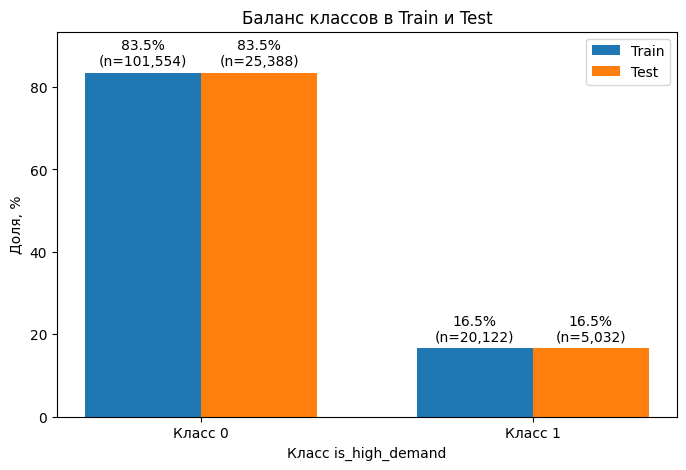

In [8]:
# Доли классов
train_percent = y_train.value_counts(normalize=True).sort_index() * 100
test_percent = y_test.value_counts(normalize=True).sort_index() * 100

# Позиции
x = [0, 1]
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_train = ax.bar([i - width / 2 for i in x], train_percent.values, width, label='Train')

bars_test = ax.bar([i + width / 2 for i in x], test_percent.values, width, label='Test')

# Подписи процентов
for bars, counts, total in [
    (bars_train, train_percent, len(y_train)),
    (bars_test, test_percent, len(y_test))
]:
    for bar, percent in zip(bars, counts.values):
        height = bar.get_height()
        # Количество объектов данного класса
        class_count = round(percent / 100 * total)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{percent:.1f}%\n(n={class_count:,})',
            ha='center',
            va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(['Класс 0', 'Класс 1'])
ax.set_ylabel('Доля, %')
ax.set_xlabel('Класс is_high_demand')
ax.set_title('Баланс классов в Train и Test')
ax.legend()

plt.ylim(0, max(train_percent.max(), test_percent.max()) + 10)
plt.show()

**Баланс классов в `train` и `test`:**

В обеих выборках наблюдается идентичный баланс: преобладающий «Класс 0» составляет 83,5%, а «Класс 1» занимает 16,5%.

## 3. Baseline

Постройте простую базовую модель: она задаст точку отсчёта для всех последующих экспериментов. Если сложная модель едва бьёт baseline — стоит задуматься.

Зафиксируйте метрики базовой модели в таблице экспериментов далее в этом уроке.

В качестве базовой модели используем Логистическую регрессию. Для работы с текстовыми подходит класс TfidfVectorizer. Английские стоп-слова в нём есть, загружаем дополнительно русские:

In [6]:
# Загружаем список стоп-слов 
nltk.download('stopwords')
russian_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Создаём для заполнения пропущенных значений и создания новых признаков:

In [ ]:
#  Функции, которые НЕ покрываются SimpleImputer 

# Извлечение количества ванных из текста
def extract_bathrooms(text):
    if pd.isna(text):
        return None
    text = text.lower()
    if 'half-bath' in text:
        return 0.5
    match = re.search(r'([\d.]+)', text)
    if match:
        return float(match.group(1))
    return None

# Заполнение пропусков в ванных
def fill_bathrooms(df):
    df = df.copy()
    df['bathrooms_from_text'] = df['bathrooms_text'].apply(extract_bathrooms)
    mask = df['bathrooms'].isnull() & df['bathrooms_from_text'].notna()
    df.loc[mask, 'bathrooms'] = df.loc[mask, 'bathrooms_from_text']
    df['bathrooms'] = df['bathrooms'].fillna(0)
    df = df.drop(columns=['bathrooms_from_text'])
    return df

# Заполнение пропусков в спальнях и кроватях
def fill_bedrooms_beds_by_accommodates(df):
    df = df.copy()
    for col in ['bedrooms', 'beds']:
        medians = df.groupby('accommodates')[col].transform('median')
        df[col] = df[col].fillna(medians)
        df[col] = df[col].fillna(df[col].median())
    return df

# Обрезка по 99 процентилю
def clip_99_percentile(df):
    df = df.copy()
    cols = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights',
            'maximum_nights', 'minimum_nights_avg_ntm']
    for col in cols:
        if col in df.columns:
            df[col] = df[col].clip(upper=df[col].quantile(0.99))
    return df

# Создание новых функций
def create_features(df):
    """Feature engineering (все новые признаки)."""
    df = df.copy()
    # host_verifications -> 3 бинарных
    hv = df['host_verifications'].fillna('').astype(str).str.lower()
    df['has_email_verification'] = hv.str.contains('email').astype(int)
    df['has_phone_verification'] = hv.str.contains('phone').astype(int)
    df['has_work_email_verification'] = hv.str.contains('work_email').astype(int)
    # is_shared_bathroom
    bt = df['bathrooms_text'].fillna('').astype(str).str.lower()
    df['is_shared_bathroom'] = bt.str.contains('shared').astype(int)
    # бинарные -> int (0/1), пропуски -> 0
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        df[col] = df[col].fillna("False").astype(str).str.lower().map(
            {'true': 1, 't': 1, '1': 1, 'false': 0, 'f': 0, '0': 0}
        ).fillna(0).astype(int)
    # производные
    df['host_trust_score'] = (
        df['has_email_verification'] + df['has_phone_verification'] +
        df['has_work_email_verification'] +
        df['host_identity_verified'] + df['host_has_profile_pic']
    )
    df['guests_per_bedroom'] = np.where(
        df['bedrooms'] > 0, df['accommodates'] / df['bedrooms'], 0
    )
    df['amenities_count'] = df['amenities'].apply(
        lambda x: x.count(',') + 1 if x != '[]' else 0
    )
    return df


def pre_feature_engineering(df):
    """Шаги, которые должны пройти ДО feature engineering."""
    df = df.copy()
    df = fill_bathrooms(df)
    df = fill_bedrooms_beds_by_accommodates(df)
    df = clip_99_percentile(df)
    return df

# Полная предобработка
def full_preprocessing(df):
    df = df.copy()
    df = pre_feature_engineering(df)
    df = create_features(df)
    return df


# Обработка пробелов в признаке удобств
def amenities_preprocessor(text):
    """'["Wifi", "Lock on bedroom door"]' -> 'Wifi Lock_on_bedroom_door'."""
    if pd.isna(text):
        return ''
    try:
        items = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return ''
    if not isinstance(items, list):
        return ''
    return ' '.join(str(item).replace(' ', '_') for item in items)

Создаём список признаков и полный пайплан модели:

In [ ]:
# Списки признаков

cat_lr_features = ['property_type', 'neighbourhood_cleansed']
nights_features = ['minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
                   'maximum_minimum_nights', 'minimum_nights_avg_ntm']
binary_features = ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
other_num_features = [
    'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'has_email_verification',
    'has_work_email_verification', 'is_shared_bathroom',
    'host_trust_score', 'guests_per_bedroom', 'amenities_count'
]
# host_listings_count обрабатывается отдельным импутером (constant=1)


# Пайплайн

preprocessing_transformer = FunctionTransformer(full_preprocessing, validate=False)

preprocessor = ColumnTransformer(transformers=[
    ('target', TargetEncoder(smooth='auto'), cat_lr_features),
    ('binary', 'passthrough', binary_features),

    # медиана для nights-признаков
    ('nights', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), nights_features),

    # константа 1 для host_listings_count
    ('host_listings', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=1)),
        ('scaler', StandardScaler()),
    ]), ['host_listings_count']),

    # остальные числовые — просто скейлим (пропусков быть не должно)
    ('num', StandardScaler(), other_num_features),

    ('tfidf_name', TfidfVectorizer(
        stop_words=russian_stop_words,
        max_features=1000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.8
    ), 'name'),
    ('tfidf_amenities', TfidfVectorizer(
        preprocessor=amenities_preprocessor,
        min_df=100
    ), 'amenities'),
], remainder='drop')

base_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_transformer),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

Проверяем работу базовой модели с кроссвалидацией:

In [9]:
# Определяем словарь нужных метрик
scoring_metrics = {"precision": "precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall"}

# Настраиваем стратифицированное разбиение с перемешиванием
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Запускаем кросс-валидацию, передав stratified_cv в параметр cv
cv_results = cross_validate(
    base_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,  
    scoring=scoring_metrics,
    n_jobs=-1)

# Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")


--- Результаты кросс-валидации (Mean) ---
Главная метрика -> Precision: 0.5540
Recall:                         0.1612
F1-Score:                       0.2497
ROC-AUC:                        0.7856


**Метрики baseline и выводы:**

Модель демонстрирует умеренную точность по главной метрике (Precision = 0.5540), правильно классифицируя лишь половину объектов, отнесенных к целевому классу. При этом наблюдается критически низкий охват (Recall = 0.1612), из-за чего модель пропускает подавляющее большинство реальных объектов «Класса 1» и выдает слабый итоговый баланс F1-Score (0.2497). Высокое значение ROC-AUC (0.7856) указывает на хороший разделительный потенциал вероятностей, который можно реализовать в пользу Precision путем ручной настройки порога классификации.

## 4. Эксперименты с моделями

Попробуйте обучить разные модели и наборы признаков. Каждый эксперимент фиксируйте в таблице.

> Если класс несбалансирован, то учитывайте это при выборе метрик и настройке моделей. Обоснуйте выбор.

> Тестовая выборка используется **только один раз** — для финальной оценки лучшей модели. Не используйте её во время экспериментов.

Создаём функции для бустинга:

In [ ]:
# Stateless FE (без статистик по датасету) 

def extract_bathrooms(text):
    if pd.isna(text):
        return None
    text = text.lower()
    if 'half-bath' in text:
        return 0.5
    match = re.search(r'([\d.]+)', text)
    if match:
        return float(match.group(1))
    return None

def fill_bathrooms(df):
    df = df.copy()
    df['bathrooms_from_text'] = df['bathrooms_text'].apply(extract_bathrooms)
    mask = df['bathrooms'].isnull() & df['bathrooms_from_text'].notna()
    df.loc[mask, 'bathrooms'] = df.loc[mask, 'bathrooms_from_text']
    df['bathrooms'] = df['bathrooms'].fillna(0)
    return df.drop(columns=['bathrooms_from_text'])

def amenities_preprocessor(text):
    """'["Wifi", "Lock on bedroom door"]' -> 'Wifi Lock_on_bedroom_door'."""
    if pd.isna(text):
        return ''
    try:
        items = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return ''
    if not isinstance(items, list):
        return ''
    return ' '.join(str(item).replace(' ', '_') for item in items)

def create_features(df):
    """Feature engineering — только построчные операции."""
    df = df.copy()

    # host_verifications -> 3 бинарных
    hv = df['host_verifications'].fillna('').astype(str).str.lower()
    df['has_email_verification']      = hv.str.contains('email').astype(int)
    df['has_phone_verification']      = hv.str.contains('phone').astype(int)
    df['has_work_email_verification'] = hv.str.contains('work_email').astype(int)

    # is_shared_bathroom
    bt = df['bathrooms_text'].fillna('').astype(str).str.lower()
    df['is_shared_bathroom'] = bt.str.contains('shared').astype(int)

    # бинарные -> int (0/1)
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        df[col] = (df[col].fillna("False").astype(str).str.lower()
                   .map({'true': 1, 't': 1, '1': 1,
                         'false': 0, 'f': 0, '0': 0})
                   .fillna(0).astype(int))

    # производные
    df['host_trust_score'] = (
        df['has_email_verification'] + df['has_phone_verification'] +
        df['has_work_email_verification'] +
        df['host_identity_verified'] + df['host_has_profile_pic']
    )
    df['guests_per_bedroom'] = np.where(
        df['bedrooms'] > 0, df['accommodates'] / df['bedrooms'], 0
    )
    # amenities_count — до нормализации строки, считаем по запятым
    df['amenities_count'] = df['amenities'].apply(
        lambda x: (str(x).count(',') + 1) if (pd.notna(x) and str(x) != '[]') else 0
    )
    return df

def pre_feature_engineering_stateless(df):
    """Построчные шаги. БЕЗ медиан по датасету (это будет в stateful)."""
    df = df.copy()
    df = fill_bathrooms(df)
    return df

In [11]:
def fit_stateful_stats(df):
    """Статистики с train. Возвращает dict."""
    stats = {}
    # медианы bedrooms/beds по accommodates
    stats['bedrooms_by_acc'] = df.groupby('accommodates')['bedrooms'].median()
    stats['beds_by_acc']     = df.groupby('accommodates')['beds'].median()
    stats['bedrooms_global'] = df['bedrooms'].median()
    stats['beds_global']     = df['beds'].median()

    # 99-й процентиль
    clip_cols = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights',
                 'maximum_nights', 'minimum_nights_avg_ntm']
    stats['clip_upper'] = {
        col: df[col].quantile(0.99) for col in clip_cols if col in df.columns
    }
    return stats

def apply_stateful_stats(df, stats):
    df = df.copy()
    for col in ['bedrooms', 'beds']:
        medians = df['accommodates'].map(stats[f'{col}_by_acc'].to_dict())
        df[col] = df[col].fillna(medians)
        df[col] = df[col].fillna(stats[f'{col}_global'])
        if pd.isna(stats[f'{col}_global']):
            df[col] = df[col].fillna(0)
    for col, upper in stats['clip_upper'].items():
        df[col] = df[col].clip(upper=upper)
    return df

Определяем список признаков:

In [ ]:
text_features = ['name', 'amenities']

cat_features = ['property_type', 'neighbourhood_cleansed', 'room_type',
    'has_phone_verification',           
    'host_has_profile_pic', 'host_identity_verified', 'instant_bookable',
    'has_email_verification', 'has_work_email_verification',
    'is_shared_bathroom']

num_features_cb = ['host_listings_count', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_nights_avg_ntm',
    'host_trust_score', 'guests_per_bedroom', 'amenities_count']

all_features = num_features_cb + cat_features + text_features

Подготавливем датасеты и обучаем модель:

In [ ]:
#  Сплит ДО статистик
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

#  Stateless (построчно)
X_tr_s = create_features(pre_feature_engineering_stateless(X_tr_raw))
X_val_s = create_features(pre_feature_engineering_stateless(X_val_raw))

#  Stateful — статистики ТОЛЬКО с train
stats = fit_stateful_stats(X_tr_s)
X_tr_f = apply_stateful_stats(X_tr_s, stats)
X_val_f = apply_stateful_stats(X_val_s, stats)

#  amenities -> строка без пробелов (ПОСЛЕ amenities_count!)
X_tr_f['amenities'] = X_tr_f['amenities'].apply(amenities_preprocessor)
X_val_f['amenities'] = X_val_f['amenities'].apply(amenities_preprocessor)

#  Приводим категориальные и текстовые к object + чистим суррогаты
def fix_surrogates(s):
    if not isinstance(s, str):
        s = str(s)
    try:
        return s.encode('utf-16', 'surrogatepass').decode('utf-16')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s.encode('utf-8', 'replace').decode('utf-8')

for df in (X_tr_f, X_val_f):
    for col in cat_features + text_features:
        arr = np.fromiter(
            (fix_surrogates(s) for s in df[col].tolist()),
            dtype=object,
            count=len(df)
        )
        df.isetitem(df.columns.get_loc(col), arr)

#  Явная проверка колонок
missing = set(all_features) - set(X_tr_f.columns)
assert not missing, f"Missing features: {missing}"

#  Pool + обучение
train_pool = Pool(X_tr_f[all_features], y_tr,
                  cat_features=cat_features,
                  text_features=text_features)
val_pool   = Pool(X_val_f[all_features], y_val,
                  cat_features=cat_features,
                  text_features=text_features)

model_cb = CatBoostClassifier(random_seed=42, verbose=False)

model_cb.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

CatBoostClassifier(random_seed=42, verbose=False)

In [17]:
# Получаем предсказания и считаем метрики
y_pred = model_cb.predict(val_pool)
y_proba = model_cb.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost 'из коробки' ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost 'из коробки' ---
Главная метрика -> Precision: 0.6355
Recall:                         0.2109
F1-Score:                       0.3167
ROC-AUC:                        0.8188


Переход на CatBoost дал  прирост по всем показателям. Главная метрика Precision выросла до 0.6355, а Recall увеличился по сравнению с логистической регрессией. Высокое значение ROC-AUC (0.8188) подтверждает, что нелинейные алгоритмы бустинга гораздо эффективнее связывают между собой районы, типы недвижимости и текстовые эмбеддинги. Модель «из коробки» показала отличный потенциал для работы с дисбалансом.

### 4.1 Таблица экспериментов

Заполняйте таблицу по мере обучения моделей:



| № | Алгоритм | Признаки | Дисбаланс | ROC-AUC | F1 | Precision | Recall | Примечание |
|---|----------|----------|-----------|---------|----|-----------|---------|-----------|
| 1 | Baseline | Все, кроме city, room_type и has_phone_verification | 83.5\16.5 |0.7856 | 0.2497|0.5540 | 0.1612| LogisticRegression|
| 2 |CatBoost 'из коробки' |Все | 83.5\16.5| 0.8188| 0.3167|0.6355 |0.2109 | |
| 3 |LogisticRegression с балансировкой классов | Все, кроме city, room_type и has_phone_verification|class_weight ='balanced' |0.7847 |0.4500 |0.3266 |0.7230 | |
| 4 |LogisticRegression с регуляризацией | Все, кроме city, room_type и has_phone_verification|83.5\16.5 |0.7516 |0.0909 |0.5338 |0.0497 |C=0.01, penalty='l1', solver='saga' |
| 5 | CatBoostClassifier с балансировкой классов|Все | scale_pos_weight =2.5|0.8213 | 0.4913|0.4814 |0.5016 | |
| 6 | CatBoostClassifier с регуляризацией|Все |83.5\16.5 | 0.8094|0.2690| 0.6453|0.1699 | iterations=2000, learning_rate=0.02, depth=5, l2_leaf_reg=10|
| 7 |CatBoostClassifier с регуляризацией и более мягкой балансировкой |Все и дополнительная обработка текстовых | scale_pos_weight =1.5|0.8125 |0.3953 | 0.5548|0.3071 ||

### 4.2 Эксперименты

Так как в целевой переменной наблюдается сильный дисбаланс 83.5\16.5 добавим в линейную модель параметр балансировки class_weight='balanced'.

In [ ]:
# Эксперимент 1
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_transformer),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))])

# Запускаем кросс-валидацию
cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,  
    scoring=scoring_metrics,
    n_jobs=-1)

#  Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации с балансом классов (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")


--- Результаты кросс-валидации с балансом классов (Mean) ---
Главная метрика -> Precision: 0.3266
Recall:                         0.7230
F1-Score:                       0.4500
ROC-AUC:                        0.7847


Использование параметра class_weight='balanced' кардинально изменило поведение модели, заставив её отдавать приоритет полноте в ущерб точности предсказаний. В результате Recall успешно увеличился до 0.7230, однако главная метрика Precision критически упала до 0.3266 из-за резкого роста ложноположительных срабатываний. Рост итогового F1-Score (0.45) и стабильный ROC-AUC (0.7847) подтверждают общую адекватность модели, но для достижения высоких бизнес-метрик данный режим балансировки неприемлем из-за чрезмерного снижения точности.

В линейную модель добавляем регуляризацию, чтобы избежать переобучения. Используем penalty='l1', так модель обнулит веса признаков, которые мало влияют на результат. 

In [19]:
# Эксперимент 2
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_transformer),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.01, penalty='l1', solver='saga', random_state=42, max_iter=1000))])

# Запускаем кросс-валидацию, передав stratified_cv в параметр cv
cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,
    scoring=scoring_metrics,
    n_jobs=-1)

#  Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации с регуляризацией (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")

--- Результаты кросс-валидации с регуляризацией (Mean) ---
Главная метрика -> Precision: 0.5238
Recall:                         0.0497
F1-Score:                       0.0909
ROC-AUC:                        0.7516


Введение L1-регуляризации с жестким коэффициентом C=0.01 заставило модель радикально занулить слабые признаки, повысив точность (Precision = 0.5338) за счет снижения шума в текстовых и категориальных эмбеддингах. Однако из-за чрезмерно консервативного отбора признаков пострадал охват (Recall = 0.0497), так как алгоритм теперь предсказывает целевой класс только при абсолютной уверенности. Метрика ROC-AUC осталась стабильно высокой (0.7516), что подтверждает правильный вектор настройки и открывает возможность для плавного ослабления регуляризации (например, до C=0.1) с целью вернуть баланс полноты без потери точности.

Обучаем модель с балансом классов 2.5. В датасете дисбаланс составляет 83.5\16.5, это примерно пять к одному. Но при scale_pos_weight ≈ 5 модель станет слишком чувствительной к миноритарному классу и начнёт выдавать много ложных срабатываний. Значение 2.5 даёт более умеренный сдвиг порога, модель всё ещё учитывает дисбаланс, но не жертвует точностью.

In [20]:
# Эксперимент 3
# Инициализируем и обучаем CatBoostClassifier
model = CatBoostClassifier(random_seed=42, verbose=False, scale_pos_weight=2.5)

model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с настройкой баланса ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с настройкой баланса ---
Главная метрика -> Precision: 0.4814
Recall:                         0.5016
F1-Score:                       0.4913
ROC-AUC:                        0.8213


Установка параметра scale_pos_weight=2.5 позволила найти компромисс между точностью и полнотой, сбалансировав метрики Precision (0.4814) и Recall (0.5016) практически на одном уровне. Хотя точность снизилась по сравнению с базовой моделью, охват целевого класса вырос более чем в два раза, что привело к лучшему значению F1-Score (0.4913). Стабильно высокий показатель ROC-AUC (0.8213) подтверждает, что бустинг сохраняет сильную разделительную способность.

Проверяем модель с другими параметрами для борьбы с дисбалансом и переобучением: сниженный learning_rate (0.02) и увеличенное число итераций (2000) обеспечивают стабильную и точную сходимость; уменьшенная глубина деревьев (depth=5) ограничивает сложность правил и повышает обобщение; увеличенная L2‑регуляризация (l2_leaf_reg=10) подавляет влияние шумных признаков. 

In [21]:
# Эксперимент 4
# Инициализируем модель с новыми параметрами 
model = CatBoostClassifier(
    iterations=2000,  # Увеличили (было 1000), чтобы модель успела дообучиться при малом шаге
    learning_rate=0.02,  # Уменьшили шаг (было 0.05) для более точной настройки весов
    depth=5,  # Снизили до 5 (было 6) для построения более простых и обобщенных правил
    l2_leaf_reg=10,  # Увеличили штраф в листьях (было 3), чтобы отсечь шум в текстах
    random_seed=42,
    verbose=False)

model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с регуляризацией ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с регуляризацией ---
Главная метрика -> Precision: 0.6453
Recall:                         0.1699
F1-Score:                       0.2690
ROC-AUC:                        0.8094


Показатель Precision увеличился до 0.6453 (по сравнению с 0.6355 на базовом бустинге). Снижение глубины деревьев (depth=5) и усиление регуляризации (l2_leaf_reg=10) эффективно заблокировали переобучение на редких словах, заставив модель выдавать прогнозы только при максимальной уверенности. Обратной стороной высокой точности стало ожидаемое падение полноты (Recall = 0.1699). Модель пропускает большую часть объектов высокого спроса, но если присваивает «Класс 1», то ошибается гораздо реже. Метрика ROC-AUC удерживается на высоком уровне (0.8094), что доказывает правильность архитектуры. Модель идеально ранжирует объекты по вероятностям, а значит, текущий Precision — это не случайное совпадение, а результат качественного обучения.

Проверяем работу модели с регуляризацией и меньшей балансировкой scale_pos_weight=1.5.

In [22]:
# Эксперимент 4
# Инициализируем модель с новыми параметрами 
model = CatBoostClassifier(scale_pos_weight=1.5,
    iterations=2000,  # Увеличили (было 1000), чтобы модель успела дообучиться при малом шаге
    learning_rate=0.02,  # Уменьшили шаг (было 0.05) для более точной настройки весов
    depth=5,  # Снизили до 5 (было 6) для построения более простых и обобщенных правил
    l2_leaf_reg=10,  # Увеличили штраф в листьях (было 3), чтобы отсечь шум в текстах
    random_seed=42,
    verbose=False)

model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с регуляризацией и настройкой баланса 1.5---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с регуляризацией и настройкой баланса 1.5---
Главная метрика -> Precision: 0.5548
Recall:                         0.3071
F1-Score:                       0.3953
ROC-AUC:                        0.8125


Добавление регуляризации и мягкой балансировки (scale_pos_weight=1.5) позволило модели найти компромисс между точностью и полнотой. ROC-AUC поднялся до высокого уровня 0.8125, подтверждая, что алгоритм стал намного лучше понимать контекст названий и описаний жилья. Хотя главная метрика Precision снизилась до 0.5548, охват целевого класса (Recall) вырос в два раза — до 0.3071.

## 5. Подбор гиперпараметров

Для лучшей модели из экспериментов подберите гиперпараметры через Optuna. Зафиксируйте лучшие параметры и итоговые метрики.

Если заставить Optuna максимизировать Precision напрямую на несбалансированной выборке модель выдаст класс «высокий спрос» всего для 1-2 объектов, в которых она уверена на 100%. Метрика Precision станет равной 1.0 (100%). При этом Recall упадет до нуля, а сама модель станет абсолютно бесполезной для бизнеса, так как пропустит 99% целевых объектов. ROC-AUC за счет учета всех порогов не позволит Optuna уйти в такое вырожденное состояние.

ROC-AUC обучает модель отличать «высокий спрос» от «низкого» при любых условиях. Он максимизирует способность модели присваивать объектам истинного высокого спроса более высокую вероятность, чем объектам низкого спроса.Precision настраивается постфактум.

По результатам экспериментов, лучше отказаться от балансировки и подобрать параметры для CatBoostClassifier:

In [23]:
# Отключаем лишние логи самого Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
        "random_seed": 42,
        "verbose": False,
        "loss_function": "Logloss",
        "eval_metric": "AUC"}

    try:
        # Важно: используем изолированный train_pool (X_tr)
        model = cb.CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=20, verbose=False)

        # Считаем ROC-AUC по вероятностям на валидации
        y_proba = model.predict_proba(val_pool)[:, 1]
        y_true = val_pool.get_label()

        roc_auc = roc_auc_score(y_true, y_proba)
        return roc_auc

    except cb.CatBoostError as e:
        print(f"Ошибка в трайле: {e}")
        return 0.0


# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

print("--- Запуск оптимизации гиперпараметров под ROC-AUC ---")
# Лучше поставить хотя бы 20 trials, так как параметров стало больше
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n--- Подбор завершен! ---")
print(f"Лучшее значение ROC-AUC на валидации: {study.best_value:.4f}")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


--- Запуск оптимизации гиперпараметров под ROC-AUC ---


  0%|          | 0/20 [00:00<?, ?it/s]


--- Подбор завершен! ---
Лучшее значение ROC-AUC на валидации: 0.8165
Лучшие параметры:
  learning_rate: 0.06832631781502053
  depth: 6
  l2_leaf_reg: 1.318126573499311


In [25]:
# Финальная модель по лучшим параметрам Optuna
best_model = CatBoostClassifier(
    iterations=1000,
    loss_function="Logloss",
    verbose=False,
    random_seed=42,
    **study.best_params,  # Распаковываем лучшие параметры от Optuna
)

Проверяем все метрики лучшей модели:

In [26]:
best_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=20, use_best_model=True, verbose=False)

# Получаем предсказания и считаем метрики
y_pred = best_model.predict(val_pool)
y_proba = best_model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost после Optuna ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost после Optuna ---
Главная метрика -> Precision: 0.6354
Recall:                         0.1988
F1-Score:                       0.3028
ROC-AUC:                        0.8164


Стандартный порог классификации 0.5, заложенный в алгоритмы, оптимален только для идеально сбалансированных выборок, где соотношение классов составляет 50 на 50. В данных присутствует сильный дисбаланс (83.5% объектов низкого спроса против 16.5% высокого).Поскольку модель обучалась на чистой функции потерь Logloss без искусственного завышения весов, её предсказанные вероятности калиброваны под реальный рынок. Если оставить порог 0.5, модель принимала бы решения слишком осторожно. Перебор порогов на валидационной выборке позволит управлять балансом точности и полноты в строгом соответствии с требованиями бизнеса.

 

In [27]:
# Перебираем пороги от 0.5 до 0.95
thresholds = np.linspace(0.5, 0.95, 46)
results = []

for t in thresholds:
    # Относим к высокому спросу только если вероятность >= t
    y_pred_custom = (y_proba >= t).astype(int)
    
    p = precision_score(y_val, y_pred_custom, zero_division=0)
    r = recall_score(y_val, y_pred_custom, zero_division=0)
    f1 = f1_score(y_val, y_pred_custom, zero_division=0)
    
    # Исключаем вырожденные случаи (где Recall критически мал)
    if r > 0.15:
        results.append({
            "Порог (Threshold)": t, 
            "Precision": p, 
            "Recall": r, 
            "F1-Score": f1
        })

# Превращаем в таблицу и сортируем по росту Precision
df_thresholds = pd.DataFrame(results).sort_values(by="Precision", ascending=False)

# Выводим топ-5 лучших порогов
print("--- Топ порогов для максимизации Precision ---")
print(df_thresholds.head(5).to_string(index=False))


--- Топ порогов для максимизации Precision ---
 Порог (Threshold)  Precision   Recall  F1-Score
              0.55   0.689498 0.150062  0.246480
              0.54   0.677149 0.160497  0.259490
              0.53   0.662439 0.168696  0.268911
              0.52   0.650679 0.178634  0.280312
              0.51   0.638442 0.187329  0.289666


Для максимизации Precision оптимальным выбором является порог 0.55, так как он обеспечивает наивысшую точность классификации на уровне 68.95%. Однако этот порог сильно ограничивает полноту (Recall), из-за чего модель сможет распознать лишь 15% истинно положительных объектов. Снижение порога до 0.52 плавно опускает точность до 65%, но при этом заметно улучшает баланс метрик.

**Лучшие параметры и метрики после подбора:**

Лучшие параметры:
  - learning_rate: 0.06832631781502053
  - depth: 6
  - l2_leaf_reg: 1.318126573499311
  - Threshold: 0.55

Метрики:
 -  Precision: 0.6895
 - Recall: 0.1501
 - F1-Score: 0.2464
 - ROC-AUC: 0.8165

## 6. Выбор финальной модели

Обоснуйте выбор финальной модели. Опирайтесь не только на метрики, но и на бизнес-контекст и связь с EDA.

**Обоснование выбора финальной модели:**

- Алгоритм: CatBoostClassifier с гиперпараметрами, оптимизированными через Optuna
- Признаки: все признаки оставшиеся и созданные на этапе EDA. Категориальные признаки - 'property_type', 'room_type', 'neighbourhood_cleansed'. Числовые признаки - 'host_listings_count',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_nights_avg_ntm',
    'amenities_count',
    'host_trust_score',
    'guests_per_bedroom'. Бинарные признаки - 'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'has_email_verification',
    'has_work_email_verification',
    'is_shared_bathroom',
    'has_phone_verification'. Текстовые признаки - 'name', 'amenities'.
- Метрики на валидации: Precision: 0.6895, Recall: 0.1501, F1-Score: 0.2464, ROC-AUC: 0.8165
- Почему лучше других: основная метрика Precision максимальна, при высокой разделяющей способности модели
- Связь с бизнес-задачей: если модель предсказывает объекту высокий спрос, она права в большинстве случаев. Низкий Precision означал бы выдачу рекомендаций пользователям на объекты, которые на самом деле не будут востребованы, что приведёт к снижению репутации платформы и отоку клиентов. Новые объявления без истории и отзывов будут рекомендованы в первую очередь, благодаря своим техническим параметрам.

️️После того как финальная модель выбрана, её необходимо сохранить как артефакт.

Сохраните модель в S3, чтобы она могла быть использована в продакшен-пайплайне.


In [28]:
load_dotenv()

# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(best_model, filebuffer)
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260519-341f466ae2/catboost_model.pkl


Проверяем результат:

In [29]:
bucket_name = os.getenv('S3_BUCKET')
file_key = 'catboost_model.pkl'

try:
    # Запрашиваем метаданные файла
    s3_client.head_object(Bucket=bucket_name, Key=file_key)
    print(f"✅ Файл '{file_key}' успешно найден в бакете '{bucket_name}'!")
    
except botocore.exceptions.ClientError as e:
    # Если сервер вернул 404, файла нет
    if e.response['Error']['Code'] == "404":
        print(f"❌ Файла '{file_key}' нет в бакете '{bucket_name}'.")
    else:
        # Другие ошибки (например, ошибка доступа 403)
        print(f"⚠️ Произошла ошибка при проверке: {e}")

✅ Файл 'catboost_model.pkl' успешно найден в бакете 's3-ds-20260519-341f466ae2'!


Сохраняем статистики для заполнения пропущенных значений:

In [ ]:
# Собираем статистики из train
# ВАЖНО: X_tr_s — это train ПОСЛЕ create_features, но ДО apply_stateful_stats.
# Медианы и процентили считаем на "сырых" (с NaN) значениях,
# иначе получим медиану от медиан, что разойдётся с тем,
# что делалось при обучении.

stats = {
    # медианы bedrooms / beds по accommodates
    "bedrooms_by_acc": X_tr_s.groupby("accommodates")["bedrooms"].median(),
    "beds_by_acc":     X_tr_s.groupby("accommodates")["beds"].median(),

    # глобальные медианы — на случай, если в проде попадётся accommodates,
    # которого не было в train
    "bedrooms_global": float(X_tr_s["bedrooms"].median()),
    "beds_global":     float(X_tr_s["beds"].median()),

    # 99-й процентиль для clip
    "clip_upper": {
        col: float(X_tr_s[col].quantile(0.99))
        for col in [
            "bathrooms",
            "bedrooms",
            "beds",
            "minimum_nights",
            "maximum_nights",
            "minimum_nights_avg_ntm",
        ]
        if col in X_tr_s.columns
    },
}

#  Сериализуем в pickle

buffer = io.BytesIO()
pickle.dump(stats, buffer)
buffer.seek(0)

#  Загружаем в S3

STATS_KEY = "smartscore/artifacts/preprocess_stats.pkl"

s3_client.upload_fileobj(
    Fileobj=buffer,
    Bucket=os.getenv("S3_BUCKET"),
    Key=STATS_KEY,
)

print(f"Stats сохранены в s3://{os.getenv('S3_BUCKET')}/{STATS_KEY}")

# Проверка — скачиваем обратно и смотрим содержимое

check_buffer = io.BytesIO()
s3_client.download_fileobj(
    Bucket=os.getenv("S3_BUCKET"),
    Key=STATS_KEY,
    Fileobj=check_buffer,
)
check_buffer.seek(0)

loaded_stats = pickle.load(check_buffer)

print("\nПроверка загрузки:")
print(f"  clip_upper keys:     {list(loaded_stats['clip_upper'].keys())}")
print(f"  bedrooms_global:     {loaded_stats['bedrooms_global']}")
print(f"  beds_global:         {loaded_stats['beds_global']}")
print(f"  bedrooms_by_acc[:5]: {loaded_stats['bedrooms_by_acc'].head().to_dict()}")
print(f"  Тип bedrooms_by_acc: {type(loaded_stats['bedrooms_by_acc'])}")
print(f"  Индекс bedrooms_by_acc dtype: {loaded_stats['bedrooms_by_acc'].index.dtype}")

Stats сохранены в s3://s3-ds-20260519-341f466ae2/smartscore/artifacts/preprocess_stats.pkl

Проверка загрузки:
  clip_upper keys:     ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
  bedrooms_global:     1.0
  beds_global:         2.0
  bedrooms_by_acc[:5]: {1.0: 1.0, 2.0: 1.0, 3.0: 1.0, 4.0: 1.0, 5.0: 2.0}
  Тип bedrooms_by_acc: <class 'pandas.Series'>
  Индекс bedrooms_by_acc dtype: float64


## 7. Валидация на тестовой выборке

Только сейчас — после того, как финальная модель выбрана, — нужно перейти к работе с тестовой выборкой. Сравните метрики лучшей модели на валидации и на тесте. Есть ли симптомы переобучения?

In [30]:
# === 1. Stateless-преобразования (построчные, без статистик) ===
X_test_s = create_features(pre_feature_engineering_stateless(X_test))

# === 2. Stateful-статистики из train ===
# stats уже посчитан ранее на X_tr_s
X_test_f = apply_stateful_stats(X_test_s, stats)

# === 3. amenities -> строка без пробелов ===
X_test_f['amenities'] = X_test_f['amenities'].apply(amenities_preprocessor)

# === 4. Приводим категориальные/текстовые к object + чистим суррогаты ===
def fix_surrogates(s):
    """Склеивает суррогатные пары в настоящие Unicode-символы."""
    if not isinstance(s, str):
        s = str(s)
    try:
        return s.encode('utf-16', 'surrogatepass').decode('utf-16')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s.encode('utf-8', 'replace').decode('utf-8')

for col in cat_features + text_features:
    arr = np.fromiter(
        (fix_surrogates(s) for s in X_test_f[col].tolist()),
        dtype=object,
        count=len(X_test_f)
    )
    X_test_f.isetitem(X_test_f.columns.get_loc(col), arr)

# === 5. Проверки ===
# 5.1 Все нужные колонки на месте
missing = set(all_features) - set(X_test_f.columns)
assert not missing, f"Missing features in test: {missing}"

# 5.2 Суррогатов не осталось
for col in cat_features + text_features:
    for s in X_test_f[col].tolist():
        try:
            s.encode('utf-8', 'strict')
        except UnicodeEncodeError:
            raise AssertionError(f"Суррогат остался в test.{col}")

# 5.3 Типы совпадают с train
for col in all_features:
    assert X_test_f[col].dtype == X_tr_f[col].dtype, \
        f"{col}: test={X_test_f[col].dtype}, train={X_tr_f[col].dtype}"

print("Test подготовлен ✅")

# === 6. Pool ===
test_pool = Pool(
    data=X_test_f[all_features],
    label=y_test.values if hasattr(y_test, 'values') else y_test,
    cat_features=cat_features,
    text_features=text_features,
)

# Делаем предсказания ЧЕРЕЗ ТЕСТОВЫЙ ПУЛ
print("\n--- Финальное тестирование на тестовом пуле ---")
y_proba = best_model.predict_proba(test_pool)[:, 1] # Получаем вероятности

#  Задаем порог, который вы выбрали на этапе валидации для максимизации Precision
CHOOSEN_THRESHOLD = 0.55

# Применяем кастомный порог
y_pred_custom = (y_proba >= CHOOSEN_THRESHOLD).astype(int)

# 5. Выводим честные метрики для бизнеса на тестовой выборке
print(f"\n--- Результаты CatBoost на ТЕСТЕ (Кастомный порог = {CHOOSEN_THRESHOLD}) ---")
print(f"Главная метрика -> Precision: {precision_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"Recall:                         {recall_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"F1-Score:                       {f1_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_test, y_proba):.4f}")


Test подготовлен ✅

--- Финальное тестирование на тестовом пуле ---

--- Результаты CatBoost на ТЕСТЕ (Кастомный порог = 0.55) ---
Главная метрика -> Precision: 0.6644
Recall:                         0.1582
F1-Score:                       0.2555
ROC-AUC:                        0.8204


**Метрики на тесте и выводы:**



| Метрика | Валидация | Тест | Разница (Тест − Валидация) |
| :--- | :---: | :---: | :---: |
| Precision (главная) | 0.6895 | 0.6644 | −0.0251 (−3.64%) |
| Recall | 0.1501 | 0.1582 | +0.0081 (+5.40%) |
| F1-Score | 0.2464 | 0.2555 | +0.0091 (+3.69%) |
| ROC-AUC | 0.8165 | 0.8204 | +0.0039 (+0.48%) |


 Cимптомы переобучения полностью отсутствуют. Модель стабильна. Модель показывает стабильное качество: ROC-AUC на валидации и тесте практически идентичен (0.8165 и 0.8204), что говорит об отсутствии переобучения. Главная метрика Precision немного просела на тесте (−3.64%), но осталась на хорошем уровне 0.6644 — примерно две трети положительных предсказаний оказываются верными. Recall низкий (около 0.15 на обоих срезах), то есть модель консервативна: она находит лишь малую долю всех реальных положительных объектов, зато редко ошибается.

## 8. SHAP-анализ

Проведите SHAP-анализ финальной модели. Ответьте на вопросы:
- Какие признаки модель считает наиболее важными?
- Совпадает ли результат оценки важности с гипотезами из EDA?
- Как это объяснить бизнесу? Почему результаты SHAP-анализа для него важны?

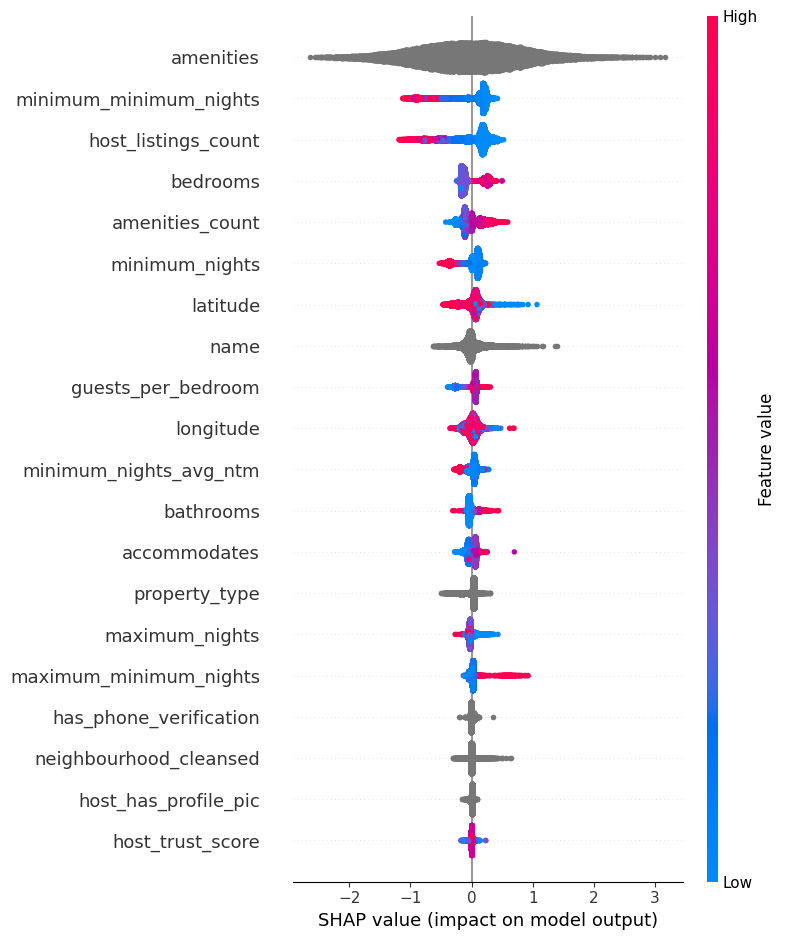

In [32]:
#  Заставляем CatBoost рассчитать SHAP-значения для тестового пула
shap_matrix = best_model.get_feature_importance(test_pool, type="ShapValues")

#  Отделяем SHAP-значения от базового смещения (последний столбец матрицы)
shap_values = shap_matrix[:, :-1]

#  Извлекаем правильные имена признаков из атрибута модели
feature_names = best_model.feature_names_

#  Строим классический summary_plot
shap.summary_plot(
    shap_values,
    X_test_f[all_features],   # ← используем подготовленный датафрейм
    feature_names=feature_names,
    max_display=20)

**Интерпретация SHAP-анализа:**

Признак amenities (Текстовое описание удобств) является самым важным признаком для модели с наибольшим разбросом значений SHAP (от -2.5 до +3). Поскольку он отображен серым цветом (текстовый эмбеддинг), отдельные слова или характеристики в названии могут как радикально увеличивать, так и уменьшать итоговое предсказание. minimum_minimum_nights (минимальный срок бронирования) имеет сильное негативное влияние при высоких значениях. Длинный шлейф розового цвета слева означает, что увеличение минимального количества ночей существенно снижает целевую метрику. host_listings_count - аналогично предыдущему признаку, большое количество объявлений у хоста (красный цвет слева) негативно сказывается на результате, в то время как единичные объявления (синий цвет справа) дают положительный вклад.

amenities_count - четко видно, что большое количество удобств (розовый цвет справа) увеличивает предсказание модели, а малое количество (синий цвет слева) — уменьшает. bedrooms - увеличение числа спален и вместимости линейно сдвигает SHAP-значения в положительную сторону.

Географические координаты (latitude и longitude) имеют сложную нелинейную зависимость. Например, для latitude определенные зоны (синий цвет далеко справа) дают сильный положительный импульс.

Признаки созданные на этапе EDA внесли значительный вклад. Общее количество удобств - amenities_count и плотность заселения - guests_per_bedroom показали свою важность для модели. У признаков bedrooms и minimum_nights была самая высокая корреляция с целевой переменной. В модели они сыграли важную роль показав 5-й и 10-й результат.

Для бизнеса важно понимать какие параметры объявления оказывают максимальное влияние на спрос. Например можно сделать выводы, что хосты с большим количеством объявлений мало заботятся о качестве жилья, делая упор на объём.  Объявления нацеленые долгосрочную аренду пользуются меньшей популярностью, чем тем, которые можно бронировать на меньший срок. Количество спален и удобств также повышаю привлекательность жилья. Также и географическое положение является важным. И, главное, текстовой описание удобств может как привлечь клиентов, так и снизить его привлекательность.

## 9. Карточка модели

Оформите карточку финальной версии модели по шаблону ниже.

### Модель v1.0

**Задача:** бинарная классификация — предсказание высокого спроса на объявление.

**Целевая переменная:** `is_high_demand`.

**Алгоритм:** CatBoostClassifier с подобранными гиперпараметрами.

**Гиперпараметры:** learning_rate - 0.06832631781502053, depth - 6, l2_leaf_reg - 1.318126573499311.

**Признаки:** Категориальные признаки - 'property_type', 'room_type', 'neighbourhood_cleansed'. Числовые признаки - 'host_listings_count',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_nights_avg_ntm',
    'amenities_count',
    'host_trust_score',
    'guests_per_bedroom'. Бинарные признаки - 'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'has_email_verification',
    'has_work_email_verification',
    'is_shared_bathroom',
    'has_phone_verification'. Текстовые признаки - 'name', 'amenities'.

**Метрики на тестовой выборке:**

| Метрика | Значение |
|---------|----------|
| ROC-AUC | 0.8204 |
| F1 |0.2555 |
| Precision |0.6644 |
| Recall |0.1582 |

**Топ-5 важных признаков по SHAP:** amenities, minimum_minimum_nights, host_listings_count, bedrooms, amenities_count.

**Ограничения модели:** Recall = 0.1582 означает, что модель находит всего ~15% от всех квартир с реальным высоким спросом. Если квартира успешна за счет какого-то одного уникального фактора, которого нет в общей массе, модель ее проигнорирует. 

**Рекомендация к внедрению:** Можно внедрять с дальнейшим усовершенствованием. Модельможет выявлять качественные объявления на основании только характеристик самого жилья, без отзывов и реакций пользователей. Это единственная возможность поднять рейтинг совершенно новых объявлений.

## 10. Итоговые выводы и рекомендации бизнесу

Напишите краткое резюме для бизнеса: что вы обучили, какого результата достигли, что рекомендуете.

**Выводы:**

Обученая модель хорошо работает с текстовыми и категориальными признаки находя нелинейные зависимости с целевой переменной. Значение ROC-AUC (0.8204) говорит о том, что модель отлично ранжирует объекты. Она выдаёт класс «высокий спрос» только тогда, когда у квартиры есть абсолютно все маркеры успеха. Но она плохо находит такие объявления. Модель обучалась на данных в которых отсутвует важный параметр объявления - дата публикации. Из-за этого не отфильтровались объявления не успевшие набрать достаточно истории за последний год и получившие таргет = 0. 

Рекомендации бизнесу:
- Ввести фильтрацию старых "спящих" объявлений под дате последней активности. Это не требует сложных алгоритмов машинного обучения.
- Использовать созданную модель для поднятия рейтинга самых свежих объявлений. Она одобряет только самую безопасную, предсказуемую и очевидную «элиту» среди объявлений.
- Предоставить для дальнейшего усовершенствования модели полные данные с датами публикаций объявлений.
